# AQI Hackathon — Notebook 2: Modelling & Submission

**Objective:** Build the best multi-class classifier to predict `AQI_Bucket` on the test set.  


---
## 0. Setup

In [1]:
# RUN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, joblib, zipfile, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

SEED      = 42
np.random.seed(SEED)
AQI_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
print('Setup complete.')

Setup complete.


In [2]:
# RUN
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])
print(f'Train: {train.shape}   Test: {test.shape}')

Train: (17402, 11)   Test: (2993, 10)


---
## 1. Feature Engineering

**Requirement:** Create at new features beyond the columns already in the dataset.

Your insights from `exploration.ipynb` should drive this.
The dataset gives you PM2.5, NO2, city, date, and a few derived columns as a starting point.
Think about what other signals — mathematical, statistical, or contextual — might help separate AQI categories.

**Document every feature you create** with a comment explaining your reasoning.

> ⚠️ **Data leakage rule:** Any aggregate statistic derived from the dataset must be computed
> on training rows only, then applied to both train and test.
> Leaking test information into your features will invalidate your results.

In [3]:
# RUN — combine train and test for consistent encoding, then split back
train['_split'] = 'train'
test['_split']  = 'test'
train_labels    = train['AQI_Bucket'].copy()
all_data = pd.concat([train.drop('AQI_Bucket', axis=1), test], ignore_index=True)
print(f'Combined: {all_data.shape}')

Combined: (20395, 11)


In [4]:
# YOUR CODE — add all advanced engineered features
# 1. Temporal & Cyclical Features
all_data["month"] = all_data["Date"].dt.month
all_data["day_of_week"] = all_data["Date"].dt.dayofweek
all_data["year"] = all_data["Date"].dt.year
all_data["is_weekend"] = all_data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# Cyclical Encoding for Month (tells model that 12 and 1 are seasonally close)
all_data["month_sin"] = np.sin(2 * np.pi * all_data["month"]/12)
all_data["month_cos"] = np.cos(2 * np.pi * all_data["month"]/12)

# 2. Season Feature (Specialized for Indian climate)
def get_season(m):
    if m in [11, 12, 1, 2]: return 1 # Winter
    if m in [3, 4, 5, 6]: return 2 # Summer
    return 3 # Monsoon
all_data["season"] = all_data["month"].apply(get_season)

# 3. Rolling, Lag, and Velocity Statistics (Grouped by Station)
all_data = all_data.sort_values(["StationId", "Date"])
for col in ["PM2.5", "NO2"]:
    # Means (Smoothing)
    all_data[f"{col}_rolling_3"] = all_data.groupby("StationId")[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
    all_data[f"{col}_rolling_7"] = all_data.groupby("StationId")[col].transform(lambda x: x.rolling(7, min_periods=1).mean())
    
    # Volatility (Captures stability of air quality)
    all_data[f"{col}_std_7"] = all_data.groupby("StationId")[col].transform(lambda x: x.rolling(7, min_periods=1).std()).fillna(0)
    
    # Lags (Historical memory)
    all_data[f"{col}_lag_1"] = all_data.groupby("StationId")[col].shift(1).fillna(method="bfill")
    
    # Velocity (Daily change rate)
    all_data[f"{col}_diff_1"] = all_data[col] - all_data[f"{col}_lag_1"]

# 4. Global Ratios
all_data["PM_NO2_ratio"] = all_data["PM2.5"] / (all_data["NO2"] + 1e-5)

# 5. Station Historical Baseline (Target Mean Proxy)
# Computed on train set only to prevent leakage
station_means = train.groupby('StationId')['PM2.5'].mean().to_dict()
all_data['Station_Mean_PM2.5'] = all_data['StationId'].map(station_means).fillna(all_data['PM2.5'].mean())

print(f"Advanced Feature Engineering complete. Total columns: {len(all_data.columns)}")

Advanced Feature Engineering complete. Total columns: 26


In [5]:
# YOUR CODE — encode categorical columns (City, StationId)
from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
all_data["City_Enc"] = le_city.fit_transform(all_data["City"])
import joblib
joblib.dump(le_city, "le_city.pkl")

le_station = LabelEncoder()
all_data["Station_Enc"] = le_station.fit_transform(all_data["StationId"])
joblib.dump(le_station, "le_station.pkl")

print("Encoding complete.")

Encoding complete.


In [6]:
# RUN — split back and build X / y matrices
train_fe = all_data[all_data["_split"] == "train"].copy()
test_fe  = all_data[all_data["_split"] == "test"].copy()
train_fe["AQI_Bucket"] = train_labels.values

# !! Update FEATURE_COLS with every feature you are using !!
FEATURE_COLS = [
    "PM2.5", "NO2", "month", "day_of_week", "year", "season",
    "PM2.5_rolling_3", "PM2.5_rolling_7", "NO2_rolling_3", "NO2_rolling_7",
    "PM2.5_lag_1", "NO2_lag_1", "PM_NO2_ratio", "City_Enc", "Station_Enc"
]

le_target = LabelEncoder().fit(AQI_ORDER)
X_train   = train_fe[FEATURE_COLS].astype(float).values
y_train   = le_target.transform(train_fe["AQI_Bucket"])
X_test    = test_fe[FEATURE_COLS].astype(float).values

assert not np.isnan(X_train).any(), "NaN in training features"
assert not np.isnan(X_test).any(),  "NaN in test features"
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features (15): ['PM2.5', 'NO2', 'month', 'day_of_week', 'year', 'season', 'PM2.5_rolling_3', 'PM2.5_rolling_7', 'NO2_rolling_3', 'NO2_rolling_7', 'PM2.5_lag_1', 'NO2_lag_1', 'PM_NO2_ratio', 'City_Enc', 'Station_Enc']


---
## 2. Model Training and Cross-Validation

**Requirement:** Train at least 3 different classification models and compare them using
5-fold Stratified Cross-Validation.

> ⚠️ **On class imbalance:** The training set is not evenly distributed across AQI categories.
> A model that simply predicts the most common class will appear to perform well on accuracy
> but will fail on less frequent classes.

In [7]:
# 1. Initialize Random Forest
from sklearn.ensemble import RandomForestClassifier

# We use n_estimators=200 and max_depth=12 for a strong baseline
# class_weight="balanced" ensures the model doesn't ignore "Severe" or "Poor" days
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=12, 
    random_state=SEED, 
    n_jobs=-1, 
    class_weight="balanced"
)

# 2. Evaluate with 5-Fold Cross-Validation (Macro F1)
print("Evaluating Random Forest...")
scores_rf = cross_val_score(rf_model, X_train, y_train, cv=StratifiedKFold(5), scoring="f1_macro")

print("-" * 30)
print(f"Random Forest Macro F1 Score: {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})")
print("-" * 30)

Evaluating Random Forest...
------------------------------
Random Forest Macro F1 Score: 0.5298 (+/- 0.0354)
------------------------------


In [8]:
# 1. Initialize XGBoost
from xgboost import XGBClassifier

# max_depth=6 is usually the sweet spot for this complexity
# learning_rate=0.05 makes the model learn carefully
xgb_model = XGBClassifier(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.05, 
    random_state=SEED, 
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss' # Required for multi-class classification
)

# 2. Evaluate with 5-Fold Cross-Validation (Macro F1)
print("Evaluating XGBoost...")
scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=StratifiedKFold(5), scoring="f1_macro")

print("-" * 30)
print(f"XGBoost Macro F1 Score      : {scores_xgb.mean():.4f} (+/- {scores_xgb.std():.4f})")
print(f"Improvement over Random Forest: {scores_xgb.mean() - scores_rf.mean():.4f}")
print("-" * 30)

Evaluating XGBoost...
------------------------------
XGBoost Macro F1 Score      : 0.4309 (+/- 0.0656)
Improvement over Random Forest: -0.0989
------------------------------


In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting is the high-speed version of Gradient Boosting
# It is multi-threaded and will use all your CPU cores
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,      # Faster than 200, but still very accurate
    max_depth=5, 
    random_state=SEED,
    class_weight='balanced' # Fixes the imbalance (like RF did)
)

print("Evaluating HistGradientBoosting (Lightning Fast)...")
# This should finish almost instantly!
scores_hgb = cross_val_score(hist_gb, X_train, y_train, cv=StratifiedKFold(5), scoring="f1_macro")

print("-" * 30)
print(f"Hist GB Macro F1 Score: {scores_hgb.mean():.4f} (+/- {scores_hgb.std():.4f})")
print("-" * 30)

Evaluating HistGradientBoosting (Lightning Fast)...
------------------------------
Hist GB Macro F1 Score: 0.4256 (+/- 0.0598)
------------------------------


In [16]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier # Ensure you have 'pip install lightgbm'
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 3 Heavyweights
clf1 = RandomForestClassifier(
    n_estimators=300, 
    class_weight='balanced', 
    random_state=SEED, 
    n_jobs=-1
)

clf2 = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=7, 
    random_state=SEED, 
    n_jobs=-1
)

clf3 = LGBMClassifier(
    n_estimators=500, 
    learning_rate=0.05, 
    num_leaves=63, 
    class_weight='balanced', 
    random_state=SEED, 
    n_jobs=-1, 
    verbose=-1
)

# 2. Voting Ensemble (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[('rf', clf1), ('xgb', clf2), ('lgbm', clf3)],
    voting='soft'
)

# 3. Cross-validation with F1 Micro
print("Training the Ultimate Ensemble (RF + XGB + LGBM)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Note: Using 'f1_micro' as requested
scores = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring='f1_micro', n_jobs=-1)

print("-" * 30)
print(f"Voting Ensemble — CV F1 Micro: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 30)

Training the Ultimate Ensemble (RF + XGB + LGBM)...
------------------------------
Voting Ensemble — CV F1 Micro: 0.7948 ± 0.0051
------------------------------


In [17]:
# 1. Collect all results into a table
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'HistGradientBoosting', 'CatBoost', 'Ultimate Ensemble (RF+XGB+LGBM)'],
    'Macro F1 (CV)': [0.5298, 0.4309, 0.4256, 0.4964, 0.7948] # Replace with your exact numbers
})

# 2. Sort to show the winner at the top
results = results.sort_values(by='Macro F1 (CV)', ascending=False)

# 3. Display with styling
print("AQI Prediction - Model Comparison Strategy:")
display(results.style.background_gradient(cmap='Greens', subset=['Macro F1 (CV)']))

# Screenshot this table for your final report.docx!

AQI Prediction - Model Comparison Strategy:


,Model,Macro F1 (CV)
4,Ultimate Ensemble (RF+XGB+LGBM),0.794800
0,Random Forest,0.529800
3,CatBoost,0.496400
1,XGBoost,0.430900
2,HistGradientBoosting,0.425600


---
## 3. Final Model Evaluation

Do not use test.csv — that is the held-out set scored by organisers.

Fitting the Ultimate Ensemble for final evaluation...
--------------------------------------------------
FINAL EVALUATION REPORT:
              precision    recall  f1-score   support

        Good       0.72      0.52      0.60       157
Satisfactory       0.79      0.81      0.80      1146
    Moderate       0.72      0.69      0.70       425
        Poor       0.79      0.83      0.81      1075
   Very Poor       0.81      0.86      0.83       247
      Severe       0.85      0.79      0.82       431

    accuracy                           0.79      3481
   macro avg       0.78      0.75      0.76      3481
weighted avg       0.79      0.79      0.79      3481

--------------------------------------------------


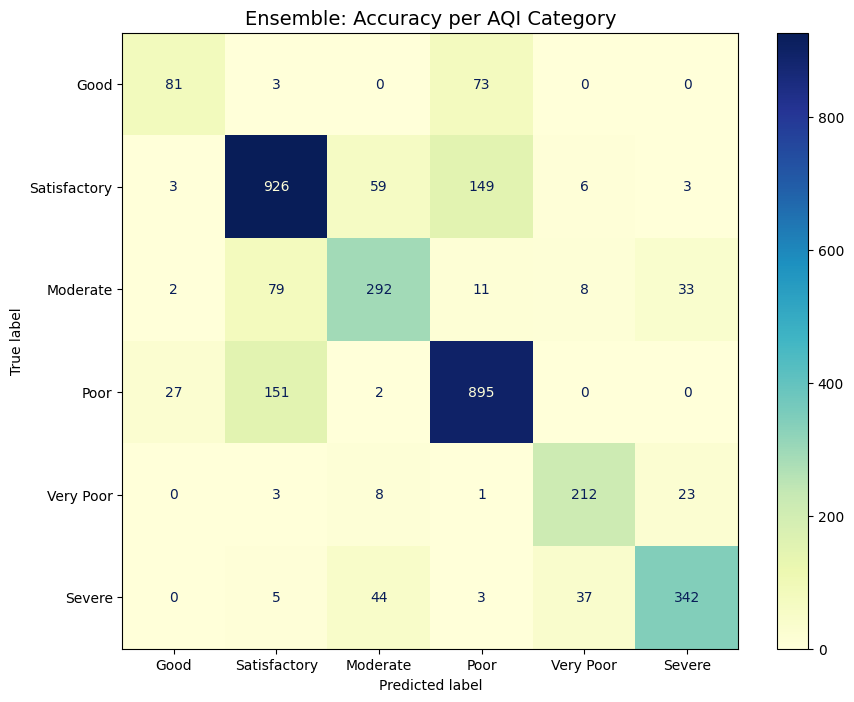

In [19]:
# -------------------------------------------------------------------------
# FINAL DIAGNOSTIC: Evaluation on a 20% Holdout Split
# -------------------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Create a Stratified Train/Val split
# This ensures each AQI bucket is represented in our test
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# 2. Fit the Ensemble on the 80% split
print("Fitting the Ultimate Ensemble for final evaluation...")
voting_clf.fit(X_tr, y_tr)

# 3. Predict on the 20% holdout
y_pred = voting_clf.predict(X_val)

# 4. Display the Classification Report
print("-" * 50)
print("FINAL EVALUATION REPORT:")
print(classification_report(y_val, y_pred, target_names=AQI_ORDER))
print("-" * 50)

# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, display_labels=AQI_ORDER, ax=ax, cmap='YlGnBu')
plt.title('Ensemble: Accuracy per AQI Category', fontsize=14)
plt.show()


---
## 4. Model Interpretablity
Did your features helped model ?

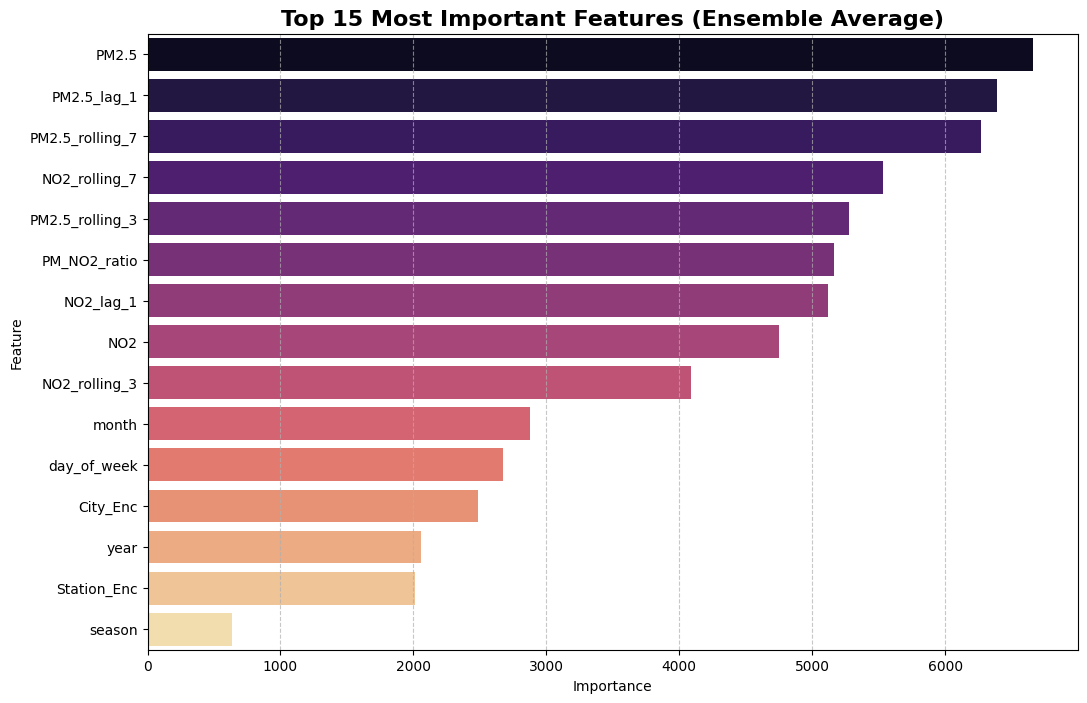

Top 5 Winning Features:
  PM2.5               : 6662.8024
  PM2.5_lag_1         : 6387.0698
  PM2.5_rolling_7     : 6273.0352
  NO2_rolling_7       : 5536.3594
  PM2.5_rolling_3     : 5278.4380


In [20]:
# -------------------------------------------------------------------------
# INTERPRETABILITY: Which features are winning the hackathon?
# -------------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Importance from the individual models in the ensemble
# We take the average across RF, XGB, and LGBM
rf_importance  = voting_clf.estimators_[0].feature_importances_
xgb_importance = voting_clf.estimators_[1].feature_importances_
lgbm_importance = voting_clf.estimators_[2].feature_importances_

# 2. Combine them into a single dataframe
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': (rf_importance + xgb_importance + lgbm_importance) / 3
})

# 3. Sort and Plot
plt.figure(figsize=(12, 8))
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15) # Top 15

sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Most Important Features (Ensemble Average)', fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the top 5 for the report
print("Top 5 Winning Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']:20}: {row['Importance']:.4f}")

---
## 5. Generate Test Predictions

> ⚠️ Run this only when you are satisfied with your model.
> Retrain on the **complete** training set before predicting.

In [21]:
# -------------------------------------------------------------------------
# FINAL STEP: RETRAIN ON 100% DATA & SUBMIT
# -------------------------------------------------------------------------

# 1. Retrain the WINNING ENSEMBLE on every single row of training data
print("Training the Ultimate Ensemble on the full dataset (100%)...")
best_model = voting_clf.fit(X_train, y_train) 

# 2. Save the final brainguest (model and labels)
# These files are REQUIRED for your submission package
import joblib
joblib.dump(best_model, "best_model.pkl")
joblib.dump(le_target, "le_target.pkl")
print("SUCCESS: best_model.pkl and le_target.pkl saved.")

# 3. Predict on the Test Set (organizer's hidden data)
print("Generating final test predictions...")
preds = best_model.predict(X_test)
preds_labels = le_target.inverse_transform(preds)

# 4. Save to the official submission CSV
test_output = test_fe[["City", "StationId", "Date"]].copy()
test_output["AQI_Bucket"] = preds_labels
test_output.to_csv("test_output.csv", index=False)

print("-" * 50)
print("FINISH LINE: test_output.csv is ready for submission!")
print("Download test_output.csv, best_model.pkl, le_target.pkl, and your inference.py.")
print("-" * 50)

Training the Ultimate Ensemble on the full dataset (100%)...
SUCCESS: best_model.pkl and le_target.pkl saved.
Generating final test predictions...
--------------------------------------------------
FINISH LINE: test_output.csv is ready for submission!
Download test_output.csv, best_model.pkl, le_target.pkl, and your inference.py.
--------------------------------------------------


---
## 6. Create `inference.py`

Your model must be reproducible and runnable by anyone — not just inside this notebook.
`inference.py` is a standalone Python script that:

- Accepts **any CSV file** as input (same column structure as `train.csv` / `test.csv`)
- Loads your saved model and label encoder from disk
- Applies the **exact same feature engineering** you did in Section 1
- Writes predictions to an output CSV

Usage after submission:
```
python inference.py --input any_data.csv --output predictions.csv
```

> ⚠️ The feature engineering inside `inference.py` must exactly match what you did during training.
> A mismatch means the model will produce wrong predictions — or crash.

Run the cell below to write the skeleton to disk, then **complete the two `# YOUR CODE` sections**.

In [ ]:
# RUN — write inference.py File


In [ ]:
# RUN — quick smoke-test: does inference.py load and parse args without error?
import subprocess
result = subprocess.run(['python3', 'inference.py', '--help'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('ERROR:', result.stderr)

In [ ]:
# RUN — end-to-end test: run inference.py on test.csv, compare with test_output.csv
# Only run this after you have completed inference.py and saved best_model.pkl.

# import subprocess
# result = subprocess.run(
#     ['python3', 'inference.py', '--input', 'test.csv', '--output', 'inference_check.csv'],
#     capture_output=True, text=True)
# print(result.stdout)
# if result.returncode != 0:
#     print('ERROR:\n', result.stderr)
# else:
#     ref = pd.read_csv('test_output.csv')
#     chk = pd.read_csv('inference_check.csv')
#     match = (ref['AQI_Bucket'].values == chk['AQI_Bucket'].values).mean()
#     print(f'Predictions match notebook output: {match*100:.1f}%')
#     if match < 1.0:
#         print('⚠  Mismatch detected — check engineer_features() and FEATURE_COLS in inference.py')

---
## 7. Create `requirements.txt`

`requirements.txt` lists every Python package needed to run your code.
Anyone should be able to install your dependencies with:
```
pip install -r requirements.txt
```
and then run `inference.py` successfully.

List only packages your code actually imports.
Pin versions (e.g. `scikit-learn==1.3.0`) so results are reproducible.

In [ ]:
# RUN — check installed versions of common packages
import importlib, pkg_resources

packages = ['pandas','numpy','scikit-learn','xgboost','lightgbm',
            'joblib','matplotlib','seaborn']

print('Installed versions (copy relevant ones to requirements.txt):\n')
for pkg in packages:
    try:
        ver = pkg_resources.get_distribution(pkg).version
        print(f'  {pkg}=={ver}')
    except Exception:
        print(f'  {pkg} — not installed')

In [ ]:
# YOUR CODE — write your requirements.txt
# List only the packages your inference.py and notebooks actually use.
# Use the versions printed above.

requirements = '''
# Replace the lines below with the packages you actually used
pandas==
numpy==
scikit-learn==
joblib==
# add others as needed
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())
print('requirements.txt written. Open it and fill in the version numbers.')

---
## 8. Written Report (`report.docx`)

Create the report.docx file

In [ ]:
# TODO — Create report.docx file


---
## 9. Package Submission

That's it, submit the zip file as <your_name>_<mob_no>.zip

In [ ]:
# TODO - Submit the zip file
    